In [22]:
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
#Will be used for smoothing
from scipy.signal import savgol_filter, find_peaks

In [ ]:
#Obtaining metadata for the video to calculate duration
cap = cv2.VideoCapture('your_video.mp4')
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
duration = frame_count / fps
cap.release()

/Users/abhinavarora/Desktop/CadenceCV/.cadence_cv/bin/python


In [ ]:
model = YOLO("yolo26n-pose.pt")  # load a pretrained model (recommended for training)
#stream=True now allows us to process the video frame by frame
source = model(source='/Users/abhinavarora/Desktop/CadenceCV/Videos/vidssave.com How 5K running paces looks on a treadmill! 15 minutes 5K. 720P.mp4', show=False, conf=0.3, stream=True)
#Result for each frame
right_ankle_coords = []
left_ankle_coords = []
frames = []
i = 0
for result in source:
    #Obtaining the first person's keypoints from the video
    if len(result.keypoints) == 0:
        continue
    kpts = result.keypoints.xy[0]
    left_ankle = kpts[15]
    right_ankle = kpts[16]
    right_ankle_coords.append(right_ankle)
    left_ankle_coords.append(left_ankle)
    i += 1
    frames.append(i)

frames = np.array(frames)
right_ankle_coords = np.array(right_ankle_coords)
left_ankle_coords = np.array(left_ankle_coords)


#Applying the savgol filter to smoothen it out and remove noise -> Easier for peak detection for cadence
window_length = 9
poly_order = 2
right_ankle_coords_smooth = savgol_filter(right_ankle_coords[:,1], window_length=window_length, polyorder=poly_order)
right_ankle_peaks = find_peaks(right_ankle_coords_smooth, None, None, 8)

left_ankle_coords_smooth = savgol_filter(left_ankle_coords[:,1], window_length=window_length, polyorder=poly_order)
left_ankle_peaks = find_peaks(left_ankle_coords_smooth, None, None, 8)

#The idea is that each peak corresponds to a step since when stepping the foot has to come to the highest y-axis. So this applies for both 
#feet so they're summed up. The total is averaged over the video duration
cadence = (len(right_ankle_peaks) + len(left_ankle_peaks)) / duration

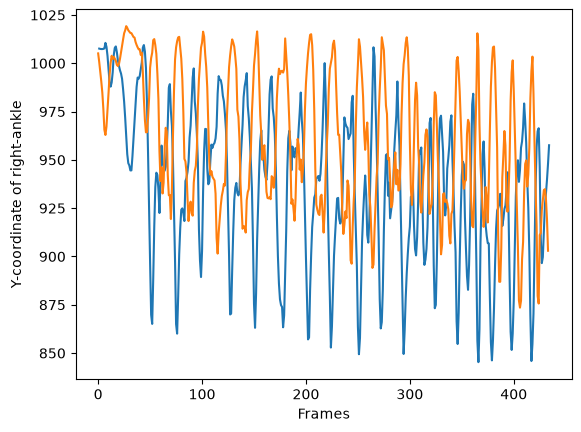

In [ ]:
#Plotting the y coordinates of the right and left ankles
plt.plot(frames, right_ankle_coords_smooth, label='right ankle')
plt.plot(frames, left_ankle_coords_smooth, label='left ankle')
plt.legend()
plt.xlabel("Frames")
plt.ylabel("Y-coordinate of ankle")
plt.show()